In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    get_ipython().run_line_magic(
        'cd',
        '..//..//content//drive//MyDrive//Colab-Notebooks//HY-673-Tutorials//Tutorial-10'
    )
except:
    pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab-Notebooks/HY-673-Tutorials/Tutorial-10


In [2]:
!pip install torchinfo

In [3]:
from librosa.filters import mel as librosa_mel_fn
import matplotlib.pyplot as plt
import numpy as np
import pathlib
import librosa
import random
import time
import os

import torch as tc
import torch.nn as nn
from torchinfo import summary
import torch.nn.functional as F
from torch.utils.data import DataLoader

device = tc.device("cuda" if tc.cuda.is_available() else "cpu")

# MelGAN Training Pipeline

We will take a closer look at a real TTS model famous for its inference speed:

![](fig/pipeline.png)
![](https://drive.google.com/uc?export=view&id=1QxZpEViH5oN1JU9mmwNWRJJMxN0WPnUP)

### <u> DSP Hyperparameters & Mel-Spectrogram</u> ###

In [4]:
fs = 22050
seq_len = 8192  # (~0.37 seconds)
no_fft = 1024
win_length = 1024
hop_length = 256
no_mels = 80
input_shape = (no_mels, seq_len//hop_length)

When MelGAN was launched, the class `torchaudio.transforms.MelSpectrogram` did not exist, so we had to manually create a class to convert a raw audio signal to a Mel-Spectrogram. Remember that we need to do that in PyTorch for speed, allow differentiability if needed, or data loading:

In [5]:
class Audio2Mel(nn.Module):
    def __init__(
        self,
        n_fft=no_fft,
        hop_len=hop_length,
        win_len=win_length,
        sr=fs,
        n_mel_channels=no_mels,
        mel_fmin=0.0,
        mel_fmax=fs/2,
    ):
        super().__init__()
        ##############################################
        # FFT Parameters                             #
        ##############################################
        window = tc.hann_window(win_len).float()
        mel_basis = librosa_mel_fn(
            sr=sr,
            n_fft=n_fft,
            n_mels=n_mel_channels,
            fmin=mel_fmin,
            fmax=mel_fmax
        )
        mel_basis = tc.from_numpy(mel_basis).float()

        self.register_buffer("mel_basis", mel_basis)
        self.register_buffer("window", window)
        self.n_fft = n_fft
        self.hop_length = hop_len
        self.win_length = win_len
        self.sampling_rate = sr
        self.n_mel_channels = n_mel_channels

    def forward(self, audio):
        p = (self.n_fft - self.hop_length) // 2
        audio = F.pad(audio, (p, p), "reflect").squeeze(1)
        stft = tc.stft(
            input=audio,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            win_length=self.win_length,
            window=self.window,
            center=False,
            return_complex=True
        )
        magnitude = tc.sqrt(stft.real ** 2 + stft.imag ** 2)
        mel_output = tc.matmul(self.mel_basis, magnitude)
        log_mel_spec = tc.log10(tc.clamp(mel_output, min=1e-5))
        return log_mel_spec

Load a speech file:

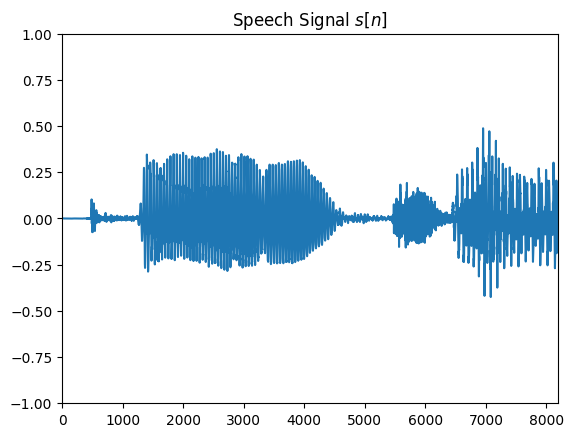

In [6]:
wav_path = os.path.join('data', 'wav')

test_sigs = np.zeros(shape=(16, seq_len))
test_sig, sampling_rate = librosa.core.load(
    os.path.join(wav_path, "LJ001-0001.wav"), sr=fs
)
test_sigs[0] = test_sig[:seq_len]

plt.figure()
plt.plot(test_sigs[0])
plt.xlim([0, seq_len])
plt.ylim([-1, 1])
plt.title("Speech Signal $s[n]$")
plt.show()
plt.close()

Plot the corresponding Mel-Spectrogram and input-output shapes to see that it is working as intended:

Input shape (time domain) = torch.Size([16, 8192])
Output shape (mel domain) = torch.Size([16, 80, 32])


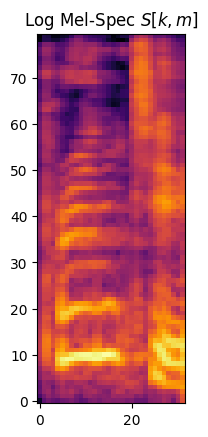

In [7]:
test_sigs = tc.from_numpy(test_sigs).to(device=device, dtype=tc.float32)

mel = Audio2Mel().to(device)
print(f"Input shape (time domain) = {test_sigs.shape}")
melspecs = mel(test_sigs)
print(f"Output shape (mel domain) = {melspecs.shape}")

plt.figure()
plt.plot()
plt.imshow(melspecs[0].cpu(), cmap="inferno")
ax = plt.gca()
ax.set_ylim(ax.get_ylim()[::-1])
plt.title("Log Mel-Spec $S[k, m]$")
plt.show()
plt.close()

In [8]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        m.weight.data.normal_(mean=0.0, std=0.02)

def wn_conv1d(*args, **kwargs):
    return nn.utils.parametrizations.weight_norm(nn.Conv1d(*args, **kwargs))

def wn_convtranspose1d(*args, **kwargs):
    return nn.utils.parametrizations.weight_norm(nn.ConvTranspose1d(*args, **kwargs))

In [9]:
# Leaky ReLU (negative) slope:
a = 0.2

In [10]:
class ResnetBlock(nn.Module):
    def __init__(self, dim, dilation=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.LeakyReLU(a),
            nn.ReflectionPad1d(padding=dilation),
            wn_conv1d(
                in_channels=dim,
                out_channels=dim,
                kernel_size=3,
                dilation=dilation
            ),
            nn.LeakyReLU(a),
            wn_conv1d(
                in_channels=dim,
                out_channels=dim,
                kernel_size=1
            ),
        )

        self.shortcut = wn_conv1d(
            in_channels=dim,
            out_channels=dim,
            kernel_size=1
        )

    def forward(self, x):
        return self.shortcut(x) + self.block(x)

# Generator

Unlike previous generators that we have seen, this one is not inputted noise, but rather a log-melspectrogram $M \times L$ to be inverted:

![](fig/generator.png)
![](https://drive.google.com/uc?export=view&id=1V42V-fRaPY0bzoBWwF8pUO_Zm-L51cgj)

In [11]:
class Generator(nn.Module):
    def __init__(self, input_size, n_residual_layers):
        super().__init__()

        no_channels = [512, 256, 128, 64, 32]
        ratios = [8, 8, 2, 2]
        self.hop_length = np.prod(ratios)

        # First layer increases the dimensionality from 80 --> 512 channels:
        model = [
            wn_conv1d(
                in_channels=input_size,
                out_channels=no_channels[0],
                kernel_size=7,
                padding='same'
            ),
        ]

        # Then follows a series of:
        for i, r in enumerate(ratios):
            # Transposed convolution to upsample x-axis and downsample y-axis:
            model += [
                nn.LeakyReLU(a),
                wn_convtranspose1d(
                    in_channels=no_channels[i],
                    out_channels=no_channels[i + 1],
                    kernel_size=r * 2,
                    stride=r,
                    padding=r // 2 + r % 2,
                    output_padding=r % 2,
                ),
            ]
            # Residual stack to progress with the transformation:
            for j in range(n_residual_layers):
                model += [
                    ResnetBlock(
                        dim=no_channels[i+1],
                        dilation=3 ** j
                    )
                ]

        # Final layer outputs the desired dimensionality 32 --> 1 channels:
        model += [
            nn.LeakyReLU(a),
            nn.ReflectionPad1d(padding=3),
            wn_conv1d(
                in_channels=no_channels[-1],
                out_channels=1,
                kernel_size=7,
                padding=0
            ),
            nn.Tanh(),
        ]

        self.model = nn.Sequential(*model)
        self.apply(weights_init)

    def forward(self, x):
        return self.model(x)

### <u>Inference:</u>

An advantage of using a fully convolutional network for our task, is that we can input Mel-Spectrogram shapes of **arbitrary length** (but not arbitrary Mel bins), because the convolution filters work irrelevant of the length of the sequence they convolve. Another important advantage is that the forward pass is fast. Let us create an instance of the model and check that the forward pass works with any length indeed:

In [12]:
batch_size = 4  # normally set to 16 for this model
n_res_layers = 3
netG = Generator(input_size=80, n_residual_layers=3).to(device=device)

print(f"Audio seq_len = {seq_len} samples long for training:")
print(f"Input shape  (time domain) = {test_sigs.shape}")
melspecs = mel(test_sigs)
print(f"Input shape  (mel domain)  = {melspecs.shape}")
out = netG(melspecs)
print(f"Output shape (time domain) = {out.shape}")

print(f"\nAudio fs = {fs} samples long for inference:")
test_sig2 = tc.from_numpy(test_sig[:fs]).view(1, fs).to(device)
print(f"Input shape  (time domain) = {test_sig2.shape}")
melspecs = mel(test_sig2)
print(f"Input shape  (mel domain)  = {melspecs.shape}")
out = netG(melspecs)
print(f"Output shape (time domain) = {out.shape}")

print(f"\nAudio 2*fs = {2*fs} samples long for inference:")
test_sig3 = tc.from_numpy(test_sig[:2*fs]).view(1, 2*fs).to(device=device)
print(f"Input shape  (time domain) = {test_sig3.shape}")
melspecs = mel(test_sig3)
print(f"Input shape  (mel domain)  = {melspecs.shape}")
out = netG(melspecs)
print(f"Output shape (time domain) = {out.shape}")

Audio seq_len = 8192 samples long for training:
Input shape  (time domain) = torch.Size([16, 8192])
Input shape  (mel domain)  = torch.Size([16, 80, 32])
Output shape (time domain) = torch.Size([16, 1, 8192])

Audio fs = 22050 samples long for inference:
Input shape  (time domain) = torch.Size([1, 22050])
Input shape  (mel domain)  = torch.Size([1, 80, 86])
Output shape (time domain) = torch.Size([1, 1, 22016])

Audio 2*fs = 44100 samples long for inference:
Input shape  (time domain) = torch.Size([1, 44100])
Input shape  (mel domain)  = torch.Size([1, 80, 172])
Output shape (time domain) = torch.Size([1, 1, 44032])


Printing the summary for the MelGAN Generator:

In [13]:
print(summary(
        model=netG,
        input_size=tuple(melspecs.shape),
        device=device
))

Layer (type:depth-idx)                                       Output Shape              Param #
Generator                                                    [1, 1, 44032]             --
├─Sequential: 1-1                                            [1, 1, 44032]             --
│    └─ParametrizedConv1d: 2-1                               [1, 512, 172]             512
│    │    └─ModuleDict: 3-1                                  --                        287,232
│    └─LeakyReLU: 2-2                                        [1, 512, 172]             --
│    └─ParametrizedConvTranspose1d: 2-3                      [1, 256, 1376]            256
│    │    └─ModuleDict: 3-2                                  --                        2,097,664
│    └─ResnetBlock: 2-4                                      [1, 256, 1376]            --
│    │    └─ParametrizedConv1d: 3-3                          [1, 256, 1376]            66,048
│    │    └─Sequential: 3-4                                  [1, 256, 1376]  

# Discriminator
![](fig/discriminator.png)
![](https://drive.google.com/uc?export=view&id=1A1o66Nsiy1BKtcH5yxFTN5ZqqWSqJXA-)

Question: What does downsampling achieve?
Answer: The effective bandwidth is decreasing, cutting off higher frequencies, so the model focuses more on lower ones which makes sense for speech synthesis.

In [14]:
class NLayerDiscriminator(nn.Module):
    def __init__(self, ndf, n_layers, downsampling_factor):
        super().__init__()
        model = nn.ModuleDict()

        model["layer_0"] = nn.Sequential(
            nn.ReflectionPad1d(7),
            wn_conv1d(1, ndf, kernel_size=15),
            nn.LeakyReLU(0.2, True),
        )

        nf = ndf
        stride = downsampling_factor
        for n in range(1, n_layers + 1):
            nf_prev = nf
            nf = min(nf * stride, 1024)

            model["layer_%d" % n] = nn.Sequential(
                wn_conv1d(
                    in_channels=nf_prev,
                    out_channels=nf,
                    kernel_size=stride * 10 + 1,
                    stride=stride,
                    padding=stride * 5,
                    groups=nf_prev // 4,
                ),
                nn.LeakyReLU(0.2, True),
            )

        nf = min(nf * 2, 1024)
        model["layer_%d" % (n_layers + 1)] = nn.Sequential(
            wn_conv1d(nf_prev, nf, kernel_size=5, stride=1, padding=2),
            nn.LeakyReLU(0.2, True),
        )

        model["layer_%d" % (n_layers + 2)] = wn_conv1d(
            nf, 1, kernel_size=3, stride=1, padding=1
        )

        self.model = model

    def forward(self, x):
        results = []
        for key, layer in self.model.items():
            x = layer(x)
            results.append(x)
        return results

In [15]:
class Discriminator(nn.Module):
    def __init__(self, num_d, ndf, n_layers, downsampling_factor):
        super().__init__()
        self.model = nn.ModuleDict()
        for i in range(num_d):
            self.model[f"disc_{i}"] = NLayerDiscriminator(
                ndf, n_layers, downsampling_factor
            )

        self.downsample = nn.AvgPool1d(4, stride=2, padding=1, count_include_pad=False)
        self.apply(weights_init)

    def forward(self, x):
        results = []
        for key, disc in self.model.items():
            results.append(disc(x))
            x = self.downsample(x)
        return results

In [16]:
num_D = 3
num_df = 16
num_layers_d = 4
downsamp_factor = 4

netD = Discriminator(
    num_d=num_D, ndf=num_df, n_layers=num_layers_d, downsampling_factor=downsamp_factor
).to(device)

# this many need to change to work in colab
print(summary(
        model=netD,
        input_size=(batch_size, 1, seq_len),
        device=device
))

Layer (type:depth-idx)                                            Output Shape              Param #
Discriminator                                                     [4, 16, 8192]             --
├─ModuleDict: 1-5                                                 --                        (recursive)
│    └─NLayerDiscriminator: 2-1                                   [4, 16, 8192]             --
│    │    └─ModuleDict: 3-1                                       --                        5,641,362
├─AvgPool1d: 1-2                                                  [4, 1, 4096]              --
├─ModuleDict: 1-5                                                 --                        (recursive)
│    └─NLayerDiscriminator: 2-2                                   [4, 16, 4096]             --
│    │    └─ModuleDict: 3-2                                       --                        5,641,362
├─AvgPool1d: 1-4                                                  [4, 1, 2048]              --
├─ModuleDict:

## <u>Dataset Handling</u> ##

We assume that we have a large enough collection of .wav audio files for training our model, such as, LJ-Speech (https://keithito.com/LJ-Speech-Dataset/). We have the choice of either computing and saving all the Mel-Spectrograms we'll need before training (=> extra disk space required), or generate them on the fly during training (=> extra computational cost during training). We will go with the second approach as in the original MelGAN repository. The steps to follow are:

1. Create two files (e.g., .txt format) that include the file names for training and testing, given a split, e.g., $90$--$10$.
2. For each training audio file:
    2.1 Get a **random** segment from the audio that is seq_len samples long. <br> 2.2 Convert segment to Mel-Spectrogram. <br> 2.3 Train the model with it (backpropagation etc.). <br>
3. An epoch has elapsed: Go to 2. until criterion is met (e.g., certain number of epochs passed).

Of course, the above is performed on **batches** of audio (batch_size), and not one audio at a time. But, the batching will be automatically handled by PyTorch's `DataLoader` - we just need to implement what happens per one file. Using this algorithm makes each epoch essentially different from one another, meaning that the model is inputted different audio segments each epoch. This strategy is common for tasks like these, because it makes the model less prone to overfitting and helps achieve better generalization. The following cell implements step 1. of the algorithm:

In [17]:
def create_dataset(path, train_percent):
    """
    Creates the train_files.txt and test_files.txt files, given a folder of ONLY .wav files (path)
    and what percentage in (0,1) of the .wav files to use for training (train_percent), a.k.a. split.
    The rest (1-train_percent) will be used for testing.
    """
    all_files = [file for file in os.listdir(path)]

    no_all_files = len(all_files)
    no_train_files = int(train_percent*no_all_files)

    train_files = all_files[0:no_train_files]
    test_files = all_files[no_train_files:no_all_files]

    with open(os.path.join(path, 'train_files.txt'), 'w') as f:
        f.write('\n'.join(train_files))
    with open(os.path.join(path, 'test_files.txt'), 'w') as f:
        f.write('\n'.join(test_files))

    return

Which can be used like so:

In [18]:
create_dataset(path=wav_path, train_percent=.8)

Now it is time for the custom dataset class, done by extending ``toch.utils.data.Dataset``. The `__init__`, `__getitem__`, and `__len__` methods need to be implemented:

In [19]:
def files_to_list(filename):
    """
    Takes a text file of filenames and makes a list of filenames.
    """
    with open(filename, encoding="utf-8") as f:
        files = f.readlines()
    return [f.rstrip() for f in files]

class AudioDataset(tc.utils.data.Dataset):
    """
    The main class for creating MelGAN's dataset.
    """
    def __init__(self, files, segment_length, sr, augment=True):
        self.sampling_rate = sr
        self.segment_length = segment_length
        self.audio_files = files_to_list(files)
        self.audio_files = [pathlib.Path(files).parent / x for x in self.audio_files]
        random.seed(1234)
        random.shuffle(self.audio_files)
        self.augment = augment

    def __getitem__(self, index):
        # Read the audio :
        filename = self.audio_files[index]
        audio, sr = self.load_wav_to_torch(filename)
        # Take a random segment :
        if audio.size(0) >= self.segment_length:
            max_audio_start = audio.size(0) - self.segment_length
            audio_start = random.randint(0, max_audio_start)
            audio = audio[audio_start: audio_start + self.segment_length]
        else:
            audio = F.pad(
                input=audio,
                pad=(0, self.segment_length - audio.size(0)),
                mode="constant",
                value=0.0
            ).data
        return audio.unsqueeze(0)

    def __len__(self):
        return len(self.audio_files)

    def load_wav_to_torch(self, full_path):
        """
        Helper method to load wav data into torch array.
        """
        data, sr = librosa.core.load(full_path, sr=self.sampling_rate)
        data = 0.95 * librosa.util.normalize(data)
        if self.augment:
            data *= np.random.uniform(low=0.3, high=1.0)
        return tc.from_numpy(data).float(), sr

And now we can create our dataloaders like so:

In [20]:
# Train and test datasets:
train_set = AudioDataset(
    files=pathlib.Path(wav_path)/"train_files.txt",
    segment_length=seq_len,
    sr=fs,
    augment=True
)
test_set = AudioDataset(
    files=pathlib.Path(wav_path)/"test_files.txt",
    segment_length=fs*4,
    sr=fs,
    augment=False
)

# Train and test data loaders:
train_loader = DataLoader(
    dataset=train_set,
    batch_size=batch_size
    # num_workers=1  # normally e.g., 4 for faster parallel loads
)
test_loader = DataLoader(
    dataset=test_set,
    batch_size=1
)

# Discriminator Loss

![](fig/discriminator-score.png)
![](https://drive.google.com/uc?export=view&id=1HHy858x7c3d7cIneP5R8HryTEXqmIOn7)

![](fig/discriminator-loss.png)
![](https://drive.google.com/uc?export=view&id=1oqzNKkjW6k2tWYIej59qeL7IkH1Kyg4c)

Question #1: By taking the $\max(0, 1-D(s))$ and $\max(0, 1+D(G(S)))$ we essentially limit the discriminator from improving past that corresponding point (i.e., 1 and -1). Why should we limit the discriminator like that?
Hint: Think of the discriminator as a classifier in this case.
Answer #1: This is done on purpose so that the network is not excessively "rewarded" for samples it already classifies correctly during training since moving too much in this direction could hinder its prediction abilities about the other samples that does not accurately assess yet. Here, it stops being rewarded when $D_k(s) = 1$ for real samples, and $D_k(G(S))=-1$ for fake ones.

Question #2: Ok, so why add $1$ in particular and not some other value e.g., 2?
Answer #2: The value itself does not really matter; what matters is the reason why it is done. Essentially, it is just another hyperparameter for tuning; 1 just happens to work well in this instance.

Question #3: Can we achieve the best of both worlds somehow?
Answer #3: In many cases we certainly can by commonly using the cross-entropy or other losses that slightly improve the discriminator for correctly classifying samples.

# Generator Loss

![](fig/generator-loss.png)
![](https://drive.google.com/uc?export=view&id=1o4Jrdo0UsvSODGcDR2a8kYCgu578jCgY)

Question: Why, with similar logic, don’t we limit the generator like we did for the discriminator’s loss?
Answer: Implicitly done for the BASE loss from the discriminator loss since every component is bounded in [0,1].

### <u>Training Loop Sketch </u> ###
With everything now put together thus far, this is how our main training loop would look like:

In [21]:
epochs = 10
lr = 1e-4
betas = (0.5, 0.9)
lambda_feat = 10
log_interval = 5

optG = tc.optim.Adam(netG.parameters(), lr=lr, betas=betas)
optD = tc.optim.Adam(netD.parameters(), lr=lr, betas=betas)

In [22]:
def train_loop():

    tc.backends.cudnn.benchmark = True
    losses = []
    costs = []
    start = time.time()
    best_mel_reconst = 1000000
    steps = 0

    for epoch in range(1, epochs + 1):
        for iterno, x_t in enumerate(train_loader):
            x_t = x_t.to(device)
            s_t = mel(x_t).detach()
            x_pred_t = netG(s_t.to(device))

            # Keep an objective score unknown to the network to measure
            # speech synthesis quality (not always reliable):
            with tc.no_grad():
                s_pred_t = mel(x_pred_t.detach())
                s_error = F.l1_loss(s_t, s_pred_t).item()

            #######################
            # Train Discriminator #
            #######################
            d_fake_det = netD(x_pred_t.to(device).detach())
            d_real = netD(x_t.to(device))

            loss_d = 0
            for scale in d_fake_det:
                loss_d += F.relu(1 + scale[-1]).mean()

            for scale in d_real:
                loss_d += F.relu(1 - scale[-1]).mean()

            netD.zero_grad()
            loss_d.backward()
            optD.step()

            ###################
            # Train Generator #
            ###################
            d_fake = netD(x_pred_t.to(device))

            loss_g = 0
            for scale in d_fake:
                loss_g += -scale[-1].mean()

            loss_feat = 0
            feat_weights = 4.0 / (num_layers_d + 1)
            d_weights = 1.0 / num_D
            wt = d_weights * feat_weights
            for i in range(num_D):
                for j in range(len(d_fake[i]) - 1):
                    loss_feat += wt * F.l1_loss(
                        d_fake[i][j], d_real[i][j].detach()
                    )

            netG.zero_grad()
            (loss_g + lambda_feat * loss_feat).backward()
            optG.step()

            costs.append(
                [loss_d.item(), loss_g.item(), loss_feat.item(), s_error]
            )
            steps += 1

            # Save samples per some iterations:
            # if steps % args.save_interval == 0:
            #     st = time.time()
            #     with tc.no_grad():
            #         for i, (voc, _) in enumerate(zip(test_voc, test_audio)):
            #             pred_audio = netG(voc).squeeze().cpu()
            #             save_sample(
            #               root / ("generated_%d.wav" % i), 22050, pred_audio
            #             )

            # Save best model based on objective metric:
            # if np.asarray(costs).mean(0)[-1] < best_mel_reconst:
            #     best_mel_reconst = np.asarray(costs).mean(0)[-1]
            #     tc.save(netD.state_dict(), "data/best_netD.pt")
            #     tc.save(netG.state_dict(), "data/best_netG.pt")

            if steps % log_interval == 0:
                print(
                    "Epoch {} | Iters {} / {} | ms/batch {:5.2f} | loss {}".format(
                        epoch,
                        iterno,
                        len(train_loader),
                        1000 * (time.time() - start) / log_interval,
                        np.asarray(costs).mean(0),
                    )
                )
                losses.append(np.asarray(costs).mean(0))
                costs = []
                start = time.time()

In [23]:
train_loop()

Epoch 2 | Iters 1 / 3 | ms/batch 3443.26 | loss [5.99884043 0.02506722 0.01892778 2.25792816]
Epoch 4 | Iters 0 / 3 | ms/batch 2486.06 | loss [5.9974349  0.03578736 0.0152905  2.16813173]
Epoch 5 | Iters 2 / 3 | ms/batch 2752.92 | loss [5.99026127 0.04661213 0.01555033 1.95827446]
Epoch 7 | Iters 1 / 3 | ms/batch 3120.88 | loss [5.9816309  0.05709554 0.01651228 1.79411557]
Epoch 9 | Iters 0 / 3 | ms/batch 2654.56 | loss [5.95477581 0.00681403 0.01939567 1.54483736]
Epoch 10 | Iters 2 / 3 | ms/batch 2606.89 | loss [ 5.87430792 -0.07339485  0.02350868  1.09861686]
